In [1]:
# Core Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from PIL import Image

# PyTorch Libraries
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [9]:
base_dir = r"C:\Users\chaka\Preethu\My_Git_Repo\Aerial_Project5\data\classification_dataset"
print("📂 Base Directory:", base_dir)
print("✅ Exists:", os.path.exists(base_dir))
print("📁 Contents:", os.listdir(base_dir))

📂 Base Directory: C:\Users\chaka\Preethu\My_Git_Repo\Aerial_Project5\data\classification_dataset
✅ Exists: True
📁 Contents: ['test', 'train', 'valid']


In [10]:
train_path = os.path.join(base_dir, "train")
valid_path = os.path.join(base_dir, "valid")    
test_path = os.path.join(base_dir, "test")

In [11]:
def inspect_structure(base_path="base_dir"):
    for root, dirs, files in os.walk(base_path):
        level = root.replace(base_path, "").count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        
        subindent = " " * 4 * (level + 1)
        for f in files[:5]:  # show only few files
            print(f"{subindent}{f}")

inspect_structure(train_path)
inspect_structure(valid_path)
inspect_structure(test_path) 

train/
    bird/
        000596bc75926abe_jpg.rf.49cf79ededcab42c160f599b1104f421.jpg
        000596bc75926abe_jpg.rf.dd331440f1cc9338d6c4ff82cd7200d6.jpg
        000712bbe0a4844f_jpg.rf.39ceec229b870fda18f3d8fb1f09af87.jpg
        000712bbe0a4844f_jpg.rf.8e869da274a69f828a31be97b34d8a32.jpg
        000f6e054dde03c8_jpg.rf.f6bc4d3376c3235f3c31171382403232.jpg
    drone/
        foto00117_png.rf.3fa4f4dbcfefb2e1eb9091247853f528.jpg
        foto00117_png.rf.f5e1d1a0734d247c460138e6b920e9ef.jpg
        foto00204_png.rf.092f4af62cef89fecc4f17dfd8353f6e.jpg
        foto00204_png.rf.c267ebe9c3475c52aa8daa9c8c6ab52a.jpg
        foto00233_png.rf.6adb431a56bde9034be4e4b7b34af083.jpg
valid/
    bird/
        000b4796f7fb05df_jpg.rf.424af2aea307cff3f4ecfc227b17493e.jpg
        001efa9e9adb51ed_jpg.rf.49044b2928813467b4b523de6e374592.jpg
        002e5a8b293ba55a_jpg.rf.5ba62ed8edc692be4f09e09b093f2200.jpg
        003fc1e9d6110dcc_jpg.rf.1a175dcb19e1247f91035c3401260557.jpg
        00570e9f0f6e1db1

In [12]:
def count_images_per_class(base_dir):
    class_counts = {}

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.jpg', '.png', '.jpeg'))
            ])
            class_counts[class_name] = count

    return class_counts

train_counts = count_images_per_class(train_path)
valid_counts = count_images_per_class(valid_path)
test_counts = count_images_per_class(test_path)
print("Train Class Counts:", train_counts)
print("Valid Class Counts:", valid_counts)  
print("Test Class Counts:", test_counts)

Train Class Counts: {'bird': 1414, 'drone': 1248}
Valid Class Counts: {'bird': 217, 'drone': 225}
Test Class Counts: {'bird': 121, 'drone': 94}


In [13]:
def check_imbalance(counts):
    total = sum(counts.values())
    
    print("\nClass Distribution:")
    for cls, count in counts.items():
        percent = (count / total) * 100
        print(f"{cls}: {count} images ({percent:.2f}%)")

    # Simple imbalance check
    max_class = max(counts.values())
    min_class = min(counts.values())

    if max_class / min_class > 1.5:
        print("\n⚠️ Imbalance detected!")
    else:
        print("\n✅ Dataset is balanced.")

check_imbalance(train_counts)
check_imbalance(valid_counts)
check_imbalance(test_counts)


Class Distribution:
bird: 1414 images (53.12%)
drone: 1248 images (46.88%)

✅ Dataset is balanced.

Class Distribution:
bird: 217 images (49.10%)
drone: 225 images (50.90%)

✅ Dataset is balanced.

Class Distribution:
bird: 121 images (56.28%)
drone: 94 images (43.72%)

✅ Dataset is balanced.


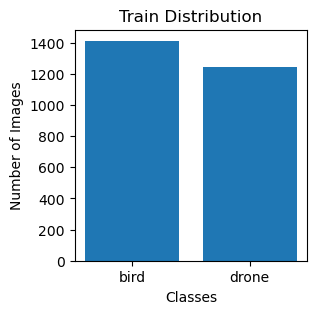

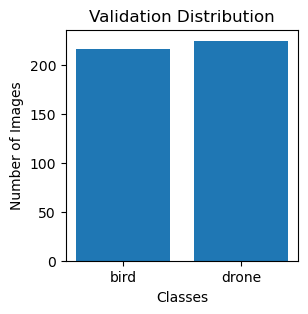

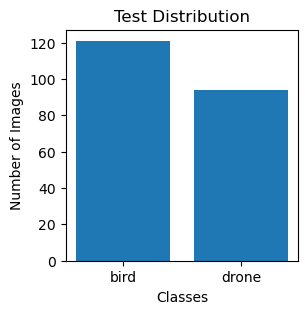

In [14]:
def plot_distribution(counts, title="Class Distribution"):
    classes = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(3,3))
    plt.subplot(1, 1, 1)
    plt.bar(classes, values)
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.title(title)
    plt.show()

plot_distribution(train_counts, "Train Distribution")
plot_distribution(valid_counts, "Validation Distribution")
plot_distribution(test_counts, "Test Distribution")

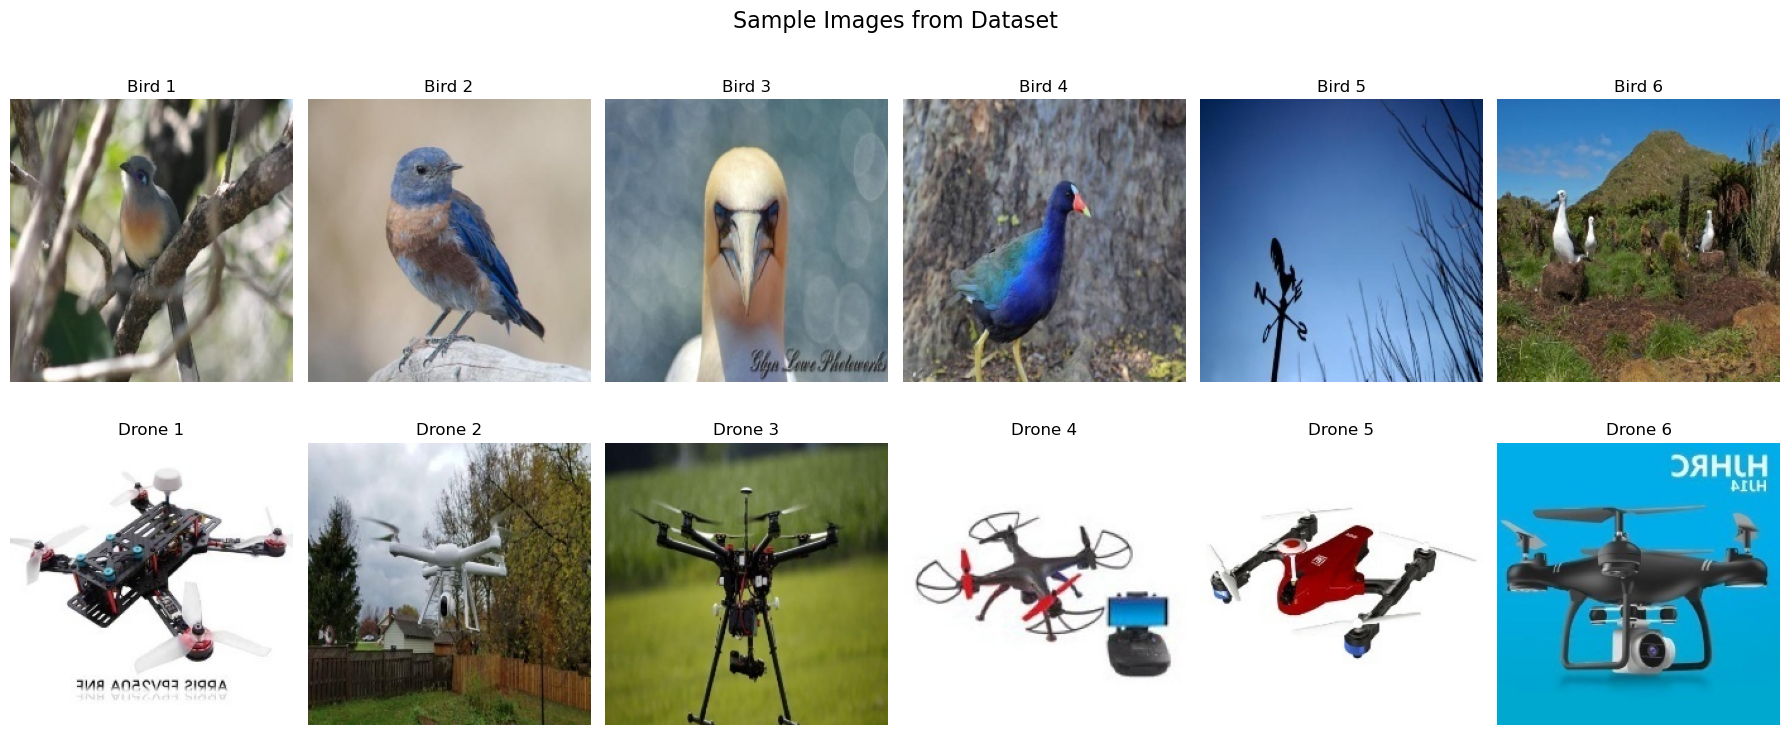

In [15]:
# Class names
classes = ['bird', 'drone']

# Display sample images from each class
def display_sample_images():
    """Display sample images from each class"""
    fig, axes = plt.subplots(2, 6, figsize=(18, 8))
    
    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(train_path, class_name)
        
        if os.path.exists(class_path):
            image_files = [f for f in os.listdir(class_path) 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            # Select 6 random images
            sample_images = random.sample(image_files, min(6, len(image_files)))
            
            for img_idx, img_file in enumerate(sample_images):
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                axes[class_idx, img_idx].imshow(img)
                axes[class_idx, img_idx].set_title(f'{class_name.capitalize()} {img_idx+1}')
                axes[class_idx, img_idx].axis('off')
    
    plt.suptitle('Sample Images from Dataset', fontsize=16)
    plt.tight_layout()
    plt.show()

display_sample_images()

In [16]:
#Define Image Parameters
# Target image size for CNN models (e.g. ResNet, MobileNet)
img_height, img_width = 224, 224
batch_size = 32

#Data Generators for Preprocessing

# Image normalization (rescale pixel values)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Create dataset generators
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir  = os.path.join(base_dir, 'test')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


c:\Users\chaka\ANACONDA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


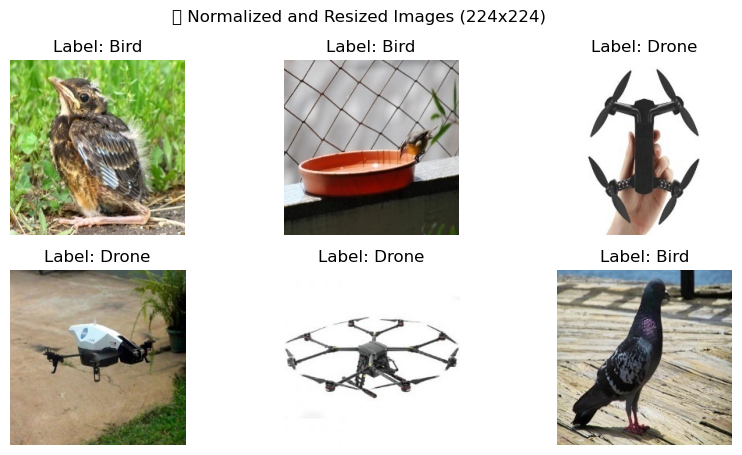

In [17]:
# Verify Sample Batch
# Get one batch of images and labels
images, labels = next(train_generator)

plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(f"Label: {'Bird' if labels[i]==0 else 'Drone'}")
    plt.axis('off')
plt.suptitle("✅ Normalized and Resized Images (224x224)")
plt.show()

In [18]:
#check the shape of the batch
print("Batch Image Shape:", images.shape)  

Batch Image Shape: (32, 224, 224, 3)


Data Augmentation

In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.Lambda(lambda x: tf.image.random_brightness(x, 0.2))
])


CNN models are sensitive to input size, so we resize all images to 224x224 pixels. Normalization (rescaling pixel values to [0,1]) helps the model converge faster during training. Data augmentation techniques like random flips, rotations, zooms, and brightness adjustments can help improve model generalization by creating variations of the training images.

In [20]:
#new model - CNN with augmentation inside the model

inputs = tf.keras.Input(shape=(224, 224, 3))

# ✅ Augmentation 
x = data_augmentation(inputs)

# Conv Block 1
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# Conv Block 2
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# Conv Block 3
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# Conv Block 4 (NEW → improves learning)
x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# Fully Connected
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Output
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,253,185 (50.56 MB)

 Trainable params: 13,251,713 (50.55 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [21]:
# Train Custom CNN
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3
    )
]

checkpoint = ModelCheckpoint(
    "saved_models/cnn_model.keras", 
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


# Train model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[callbacks, checkpoint],
    verbose=1
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6791 - loss: 0.7050
Epoch 1: val_loss improved from None to 0.69007, saving model to saved_models/cnn_model.keras

Epoch 1: finished saving model to saved_models/cnn_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.7077 - loss: 0.6422 - val_accuracy: 0.4910 - val_loss: 0.6901 - learning_rate: 1.0000e-04
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7494 - loss: 0.5442
Epoch 2: val_loss did not improve from 0.69007
84/84 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7596 - loss: 0.5335 - val_accuracy: 0.4910 - val_loss: 1.4529 - learning_rate: 1.0000e-04
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8013 - loss: 0.4651
Epoch 3: val_loss did not improve from 0.69007
84/84 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.7930 - loss: 0.4776 - val_accuracy: 0.5226 - val_loss: 1.2610 - learning_rate: 1.0000e-04
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7977

In [22]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.8837 - loss: 0.2979
Test Accuracy: 88.37%


In [23]:
from tensorflow.keras.applications import ResNet50, MobileNet, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

In [24]:
#resnet50 model with transfer learning
def build_resnet50():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # Freeze base layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

resnet_model = build_resnet50()
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [25]:
#train resnet50 with callbacks
resnet_checkpoint = ModelCheckpoint(
    'saved_models/resnet50_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
resnet_history = resnet_model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[callbacks, resnet_checkpoint],
    verbose=1
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5549 - loss: 0.7242
Epoch 1: val_loss improved from None to 0.69772, saving model to saved_models/resnet50_best.keras

Epoch 1: finished saving model to saved_models/resnet50_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.5770 - loss: 0.6948 - val_accuracy: 0.5905 - val_loss: 0.6977 - learning_rate: 0.0010
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.5825 - loss: 0.6967 
Epoch 2: val_loss improved from 0.69772 to 0.62640, saving model to saved_models/resnet50_best.keras

Epoch 2: finished saving model to saved_models/resnet50_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 915s 11s/step - accuracy: 0.6089 - loss: 0.6663 - val_accuracy: 0.6380 - val_loss: 0.6264 - learning_rate: 0.0010
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6155 - loss: 0.6427
Epoch 3: val_loss improved from 0.62640 to 0.60834, saving model to saved_models/resnet50_best.keras

Epoch 3: finished saving model 

In [26]:
	test_results = resnet_model.evaluate(test_generator)
	if isinstance(test_results, list):
		test_loss, test_acc = test_results
	else:
		test_loss = test_results
		test_acc = None
	print(f"Test Loss: {test_loss:.4f}")
	if test_acc is not None:
		print(f"Test Accuracy: {test_acc * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6465 - loss: 0.6330
Test Loss: 0.6330
Test Accuracy: 64.65%


In [27]:
def build_mobilenet():
    base_model = MobileNet(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # Freeze base layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

mobilenet_model = build_mobilenet()
mobilenet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [28]:
mobilenet_checkpoint = ModelCheckpoint(
    'saved_models/mobilenet_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
mobilenet_history = mobilenet_model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[callbacks, mobilenet_checkpoint],
    verbose=1
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8137 - loss: 0.4047
Epoch 1: val_loss improved from None to 0.08889, saving model to saved_models/mobilenet_best.keras

Epoch 1: finished saving model to saved_models/mobilenet_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 47s 531ms/step - accuracy: 0.9050 - loss: 0.2179 - val_accuracy: 0.9570 - val_loss: 0.0889 - learning_rate: 0.0010
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9683 - loss: 0.0917
Epoch 2: val_loss improved from 0.08889 to 0.08754, saving model to saved_models/mobilenet_best.keras

Epoch 2: finished saving model to saved_models/mobilenet_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 476ms/step - accuracy: 0.9730 - loss: 0.0776 - val_accuracy: 0.9706 - val_loss: 0.0875 - learning_rate: 0.0010
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.9825 - loss: 0.0541
Epoch 3: val_loss improved from 0.08754 to 0.08352, saving model to saved_models/mobilenet_best.keras

Epoch 3: finishe

In [29]:
#Evaluate model
test_results = mobilenet_model.evaluate(test_generator)
if isinstance(test_results, list):
	test_loss, test_acc = test_results
else:
	test_loss = test_results
	test_acc = None
print(f"Test Loss: {test_loss:.4f}")
if test_acc is not None:
	print(f"Test Accuracy: {test_acc * 100:.2f}%")


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 352ms/step - accuracy: 1.0000 - loss: 0.0194
Test Loss: 0.0194
Test Accuracy: 100.00%


In [30]:
def build_efficientnet():
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # Freeze base layers

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

efficientnet_model = build_efficientnet()
efficientnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [31]:
efficientnet_checkpoint = ModelCheckpoint(
    'saved_models/efficientnet_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
efficientnet_history = efficientnet_model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[callbacks, efficientnet_checkpoint],
    verbose=1
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.5065 - loss: 0.7276
Epoch 1: val_loss improved from None to 0.69282, saving model to saved_models/efficientnet_best.keras

Epoch 1: finished saving model to saved_models/efficientnet_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 623ms/step - accuracy: 0.5177 - loss: 0.7142 - val_accuracy: 0.5090 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.5026 - loss: 0.6984
Epoch 2: val_loss did not improve from 0.69282
84/84 ━━━━━━━━━━━━━━━━━━━━ 49s 587ms/step - accuracy: 0.5034 - loss: 0.6970 - val_accuracy: 0.4910 - val_loss: 0.7066 - learning_rate: 0.0010
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.4981 - loss: 0.6975
Epoch 3: val_loss did not improve from 0.69282
84/84 ━━━━━━━━━━━━━━━━━━━━ 49s 579ms/step - accuracy: 0.5139 - loss: 0.6954 - val_accuracy: 0.4910 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/s

In [32]:
#evaluate effcientnet model
test_results = efficientnet_model.evaluate(test_generator)
if isinstance(test_results, list):
	test_loss, test_acc = test_results
else:
	test_loss = test_results
	test_acc = None
print(f"Test Loss: {test_loss:.4f}")
if test_acc is not None:
	print(f"Test Accuracy: {test_acc * 100:.2f}%")


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 479ms/step - accuracy: 0.4372 - loss: 0.6957
Test Loss: 0.6957
Test Accuracy: 43.72%


In [33]:
# Reset test generator
test_generator.reset()

# Get true labels
y_true = test_generator.classes

# Predictions for each model

# Custom CNN
cnn_pred_prob = model.predict(test_generator, verbose=0)
cnn_pred = (cnn_pred_prob > 0.5).astype(int).flatten()

# ResNet50
resnet_pred_prob = resnet_model.predict(test_generator, verbose=0)
resnet_pred = (resnet_pred_prob > 0.5).astype(int).flatten()

# MobileNet
mobilenet_pred_prob = mobilenet_model.predict(test_generator, verbose=0)
mobilenet_pred = (mobilenet_pred_prob > 0.5).astype(int).flatten()

# EfficientNetB0
efficientnet_pred_prob = efficientnet_model.predict(test_generator, verbose=0)
efficientnet_pred = (efficientnet_pred_prob > 0.5).astype(int).flatten()


In [34]:
# Calculate Metrics for All Models
def calculate_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"{model_name} - METRICS")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall:    {rec*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

# Calculate metrics for all models
cnn_metrics = calculate_metrics(y_true, cnn_pred, "Custom CNN")
resnet_metrics = calculate_metrics(y_true, resnet_pred, "ResNet50")
mobilenet_metrics = calculate_metrics(y_true, mobilenet_pred, "MobileNet")
efficientnet_metrics = calculate_metrics(y_true, efficientnet_pred, "EfficientNetB0")



Custom CNN - METRICS
Accuracy:  88.84%
Precision: 89.77%
Recall:    84.04%
F1-Score:  86.81%

ResNet50 - METRICS
Accuracy:  64.65%
Precision: 100.00%
Recall:    19.15%
F1-Score:  32.14%

MobileNet - METRICS
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1-Score:  100.00%

EfficientNetB0 - METRICS
Accuracy:  43.72%
Precision: 43.72%
Recall:    100.00%
F1-Score:  60.84%


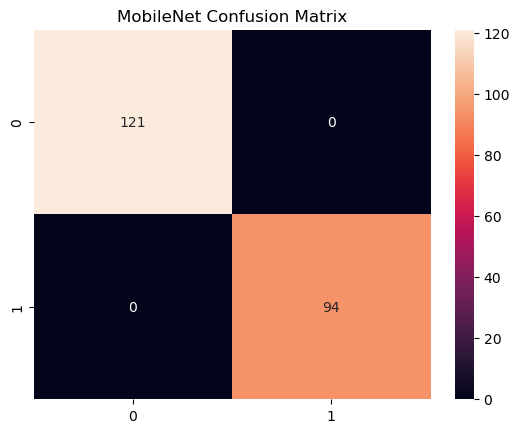

In [35]:
cm = confusion_matrix(y_true, mobilenet_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("MobileNet Confusion Matrix")
plt.show()

In [36]:
from tensorflow.keras.models import load_model

# Load the best model
best_model = load_model('saved_models/mobilenet_best.keras')
print("Best model loaded successfully.")

Best model loaded successfully.


In [38]:
#fine tuning
for layer in best_model.layers[-10:]:
        layer.trainable = True

for layer in best_model.layers[:-10]:
        layer.trainable = False

best_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
history_fine = best_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=2
        )
    ]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.9703 - loss: 0.0810 - val_accuracy: 0.9706 - val_loss: 0.1061 - learning_rate: 3.0000e-06
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 463ms/step - accuracy: 0.9786 - loss: 0.0569 - val_accuracy: 0.9706 - val_loss: 0.1057 - learning_rate: 3.0000e-06
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 526ms/step - accuracy: 0.9838 - loss: 0.0484 - val_accuracy: 0.9706 - val_loss: 0.1058 - learning_rate: 3.0000e-06
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 538ms/step - accuracy: 0.9846 - loss: 0.0476 - val_accuracy: 0.9706 - val_loss: 0.1036 - learning_rate: 3.0000e-06
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 538ms/step - accuracy: 0.9823 - loss: 0.0435 - val_accuracy: 0.9729 - val_loss: 0.0983 - learning_rate: 3.0000e-06
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 506ms/step - accuracy: 0.9838 - loss: 0.0375 - val_accuracy: 0.9729 - val_loss: 0.0959 - learning_rate: 3.0000e-06
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 529ms/step - acc

In [39]:
# Reset test generator
test_generator.reset()

# Get true labels
y_true_final = test_generator.classes

# Predictions for each model

# Custom CNN
best_pred_prob = best_model.predict(test_generator, verbose=0)
best_pred = (best_pred_prob > 0.5).astype(int).flatten()

In [41]:
#evaluate best model
test_results = best_model.evaluate(test_generator)
if isinstance(test_results, list):
	test_loss, test_acc = test_results
else:
	test_loss = test_results
	test_acc = None
print(f"Test Loss: {test_loss:.4f}")
if test_acc is not None:
	print(f"Test Accuracy: {test_acc * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.9907 - loss: 0.0200
Test Loss: 0.0200
Test Accuracy: 99.07%


In [44]:
best_model_metrics = calculate_metrics(y_true_final, best_pred, "Final Model")


Final Model - METRICS
Accuracy:  99.07%
Precision: 100.00%
Recall:    97.87%
F1-Score:  98.92%


In [47]:
#saving best model
best_model.save("saved_models/best_model.keras")